In [1]:
import kagglehub

path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
Path to dataset files: /kaggle/input/customer-segmentation-tutorial-in-python


In [2]:
import pandas as pd

df = pd.read_csv(path + "/Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [5]:

df.drop("Gender", axis=1, inplace=True)
df.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [6]:
df.tail()

,Age,Annual Income (k$),Spending Score (1-100)
195,35,120,79
196,45,126,28
197,32,126,74
198,32,137,18
199,30,137,83


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)

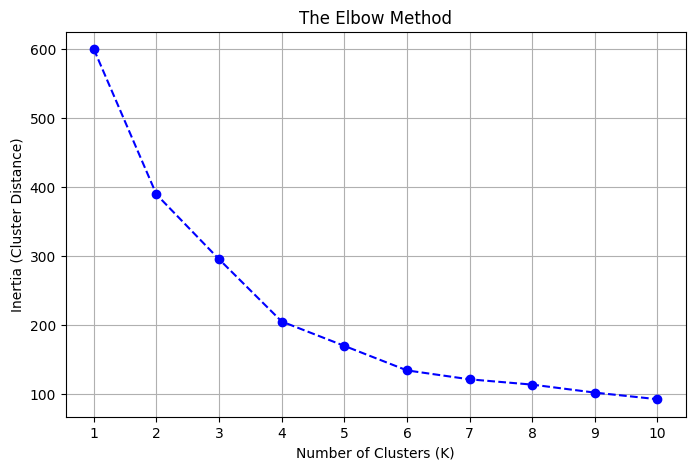

In [10]:
from matplotlib.lines import lineStyles
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia_values = []

for k in range(1,11):
  kmeans = KMeans(n_clusters=k,random_state=42)
  kmeans.fit(df_scaled)

  inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,11),inertia_values,marker="o",linestyle="--",color="b")
plt.title("The Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Cluster Distance)")
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()


In [12]:
final_kmeans = KMeans(n_clusters=5,random_state=42)
cluster_labels = final_kmeans.fit_predict(df_scaled)
df['Cluster'] = cluster_labels
print(df.head())

   Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0   19                  15                      39        2
1   21                  15                      81        2
2   20                  16                       6        3
3   23                  16                      77        2
4   31                  17                      40        2


In [16]:
cluster_analysis = df.groupby("Cluster").mean()
print(cluster_analysis.sort_values("Annual Income (k$)"))

               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
2        25.769231           26.115385               74.846154
0        55.275862           47.620690               41.706897
3        26.733333           54.311111               40.911111
1        32.875000           86.100000               81.525000
4        44.387097           89.774194               18.483871


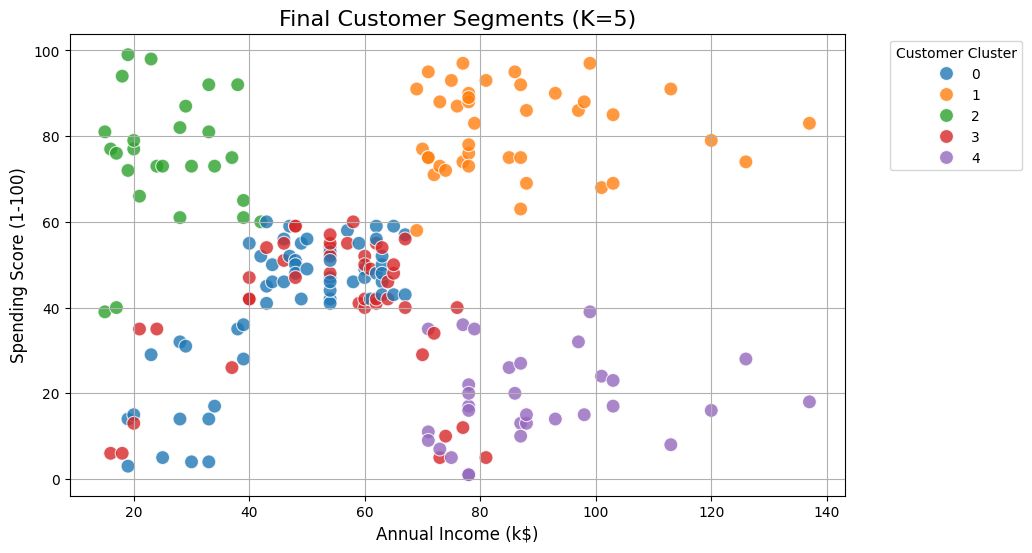

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Draw a scatter plot coloring the points by their assigned Cluster label
# We look at Income vs Spending Score because it shows the cleanest separation
sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    data=df,
    palette='tab10',
    s=100,
    alpha=0.8
)

plt.title('Final Customer Segments (K=5)', fontsize=16)
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(title='Customer Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.show()